1. Preparação do ambiente

In [ ]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

print("TensorFlow:", tf.__version__)

TensorFlow: 2.19.0


2. Reprodutibilidade

In [ ]:
SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Semente configurada:", SEED)

Semente configurada: 42


3. Importação e exibição do dataset

In [ ]:
file_path = '/content/contratos_2024_20241231.csv'
df_contratos = pd.read_csv(file_path)

print("Primeiras 5 linhas do dataset 'contratos_2024_20241231.csv':")
display(df_contratos.head())

Primeiras 5 linhas do dataset 'contratos_2024_20241231.csv':


,ug,contrato_ano,objeto,situacao,estagio,processo,fornecedor,data_inicio_vigencia,data_fim_vigencia,valor,download
0,AGêNCIA ESTADUAL DE MEIO AMBIENTE,001/2024,1.004 GÁS ENGARRAFADO,NaN,EM EXECUçãO,29/2023,33965309000175 - J M VIEIRA COMERCIO DE GAS E ...,2024/03/01 00:00:00.000,2025/02/28 00:00:00.000,7860.00,http://web.transparencia.pe.gov.br/contratos/8...
1,AGêNCIA ESTADUAL DE MEIO AMBIENTE,002/2024,2.062 PASSAGENS E DESPESAS COM LOCOMOÇÃO,NaN,EM EXECUçãO,NaN,9480880000115 - BRASLUSO TURISMO LTDA - EPP,2024/02/15 00:00:00.000,2025/02/14 00:00:00.000,150000.00,http://web.transparencia.pe.gov.br/contratos/8...
2,AGêNCIA ESTADUAL DE MEIO AMBIENTE,003/2024,2.099 SERVIÇO,NaN,EM EXECUçãO,NaN,11457039000159 - GESTÃO DE TERCEIRIZAÇÃO EM SE...,2024/03/01 00:00:00.000,2025/02/28 00:00:00.000,461999.44,http://web.transparencia.pe.gov.br/contratos/8...
3,AGêNCIA ESTADUAL DE MEIO AMBIENTE,004/2024,1.001 GÊNEROS ALIMENTÍCIOS,NaN,EM EXECUçãO,NaN,22553731000105 - A S DE LIMA COMERCIO-EPP,2024/04/01 00:00:00.000,2025/03/31 00:00:00.000,19755.00,http://web.transparencia.pe.gov.br/contratos/8...
4,AGêNCIA ESTADUAL DE MEIO AMBIENTE,005/2024,2.002 LOCAÇÃO DE BENS MÓVEIS EM GERAL,NaN,EM EXECUçãO,NaN,11897590000113 - WC LOCAçãO E SERVIçOS LTDA.,2024/04/01 00:00:00.000,2025/03/31 00:00:00.000,65499.96,http://web.transparencia.pe.gov.br/contratos/8...


In [ ]:
df_contratos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2047 entries, 0 to 2046
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ug                    2047 non-null   object 
 1   contrato_ano          2047 non-null   object 
 2   objeto                2047 non-null   object 
 3   situacao              0 non-null      float64
 4   estagio               2047 non-null   object 
 5   processo              982 non-null    object 
 6   fornecedor            2047 non-null   object 
 7   data_inicio_vigencia  2047 non-null   object 
 8   data_fim_vigencia     2047 non-null   object 
 9   valor                 2047 non-null   float64
 10  download              2036 non-null   object 
dtypes: float64(2), object(9)
memory usage: 176.0+ KB


4. Pré-processamento dos dados

4.1 Remoção de features

In [ ]:
columns_to_drop = ['situacao', 'processo', 'download']
df_contratos = df_contratos.drop(columns=columns_to_drop, errors='ignore')

print(f"Colunas '{', '.join(columns_to_drop)}' removidas.")

Colunas 'situacao, processo, download' removidas.


4.2 Conversão de valores categóricos em numéricos

In [ ]:
# Conversão de colunas de data para datetime e extração de features numéricas
for col in ['data_inicio_vigencia', 'data_fim_vigencia']:
    if col in df_contratos.columns:
        df_contratos[col] = pd.to_datetime(df_contratos[col], errors='coerce')
        df_contratos[f'{col}_ano'] = df_contratos[col].dt.year
        df_contratos[f'{col}_mes'] = df_contratos[col].dt.month
        df_contratos[f'{col}_dia'] = df_contratos[col].dt.day
        print(f"Colunas '{col}_ano', '{col}_mes', '{col}_dia' criadas a partir de '{col}'.")

# Criação de uma coluna para a duração do contrato em dias
if 'data_inicio_vigencia' in df_contratos.columns and 'data_fim_vigencia' in df_contratos.columns:
    df_contratos['duracao_dias'] = (df_contratos['data_fim_vigencia'] - df_contratos['data_inicio_vigencia']).dt.days
    print("Coluna 'duracao_dias' criada.")

# Conversão de 'contrato_ano' para numérico, extraindo apenas o ano
if 'contrato_ano' in df_contratos.columns:
    df_contratos['ano_contrato'] = df_contratos['contrato_ano'].str.extract(r'/(\d{4})$', expand=False).astype(float)
    print("Coluna 'contrato_ano' convertida para 'contrato_ano_num'.")

# Conversão de variáveis categóricas em numéricas
df_contratos['ug_num'], _ = pd.factorize(df_contratos['ug'])
print("Coluna 'ug' convertida para 'ug_num'.")

df_contratos['objeto_num'], _ = pd.factorize(df_contratos['objeto'])
print("Coluna 'objeto' convertida para 'objeto_num'.")

df_contratos['estagio_num'], _ = pd.factorize(df_contratos['estagio'])
print("Coluna 'estagio' convertida para 'estagio_num'.")

df_contratos['fornecedor_num'], _ = pd.factorize(df_contratos['fornecedor'])
print("Coluna 'fornecedor' convertida para 'fornecedor_num'.")

columns_to_drop = ['ug', 'objeto', 'estagio', 'fornecedor', 'data_inicio_vigencia', 'data_fim_vigencia', 'contrato_ano']
df_contratos = df_contratos.drop(columns=columns_to_drop, errors='ignore')

df_contratos = df_contratos.dropna()

print(f"Colunas '{', '.join(columns_to_drop)}' removidas.")
df_contratos.info()

Colunas 'data_inicio_vigencia_ano', 'data_inicio_vigencia_mes', 'data_inicio_vigencia_dia' criadas a partir de 'data_inicio_vigencia'.
Colunas 'data_fim_vigencia_ano', 'data_fim_vigencia_mes', 'data_fim_vigencia_dia' criadas a partir de 'data_fim_vigencia'.
Coluna 'duracao_dias' criada.
Coluna 'contrato_ano' convertida para 'contrato_ano_num'.
Coluna 'ug' convertida para 'ug_num'.
Coluna 'objeto' convertida para 'objeto_num'.
Coluna 'estagio' convertida para 'estagio_num'.
Coluna 'fornecedor' convertida para 'fornecedor_num'.
Colunas 'ug, objeto, estagio, fornecedor, data_inicio_vigencia, data_fim_vigencia, contrato_ano' removidas.
<class 'pandas.core.frame.DataFrame'>
Index: 2045 entries, 0 to 2046
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   valor                     2045 non-null   float64
 1   data_inicio_vigencia_ano  2045 non-null   int32  
 2   data_inicio_vigencia_mes  2045 no

4.3 Matriz de correlação para avaliar as features

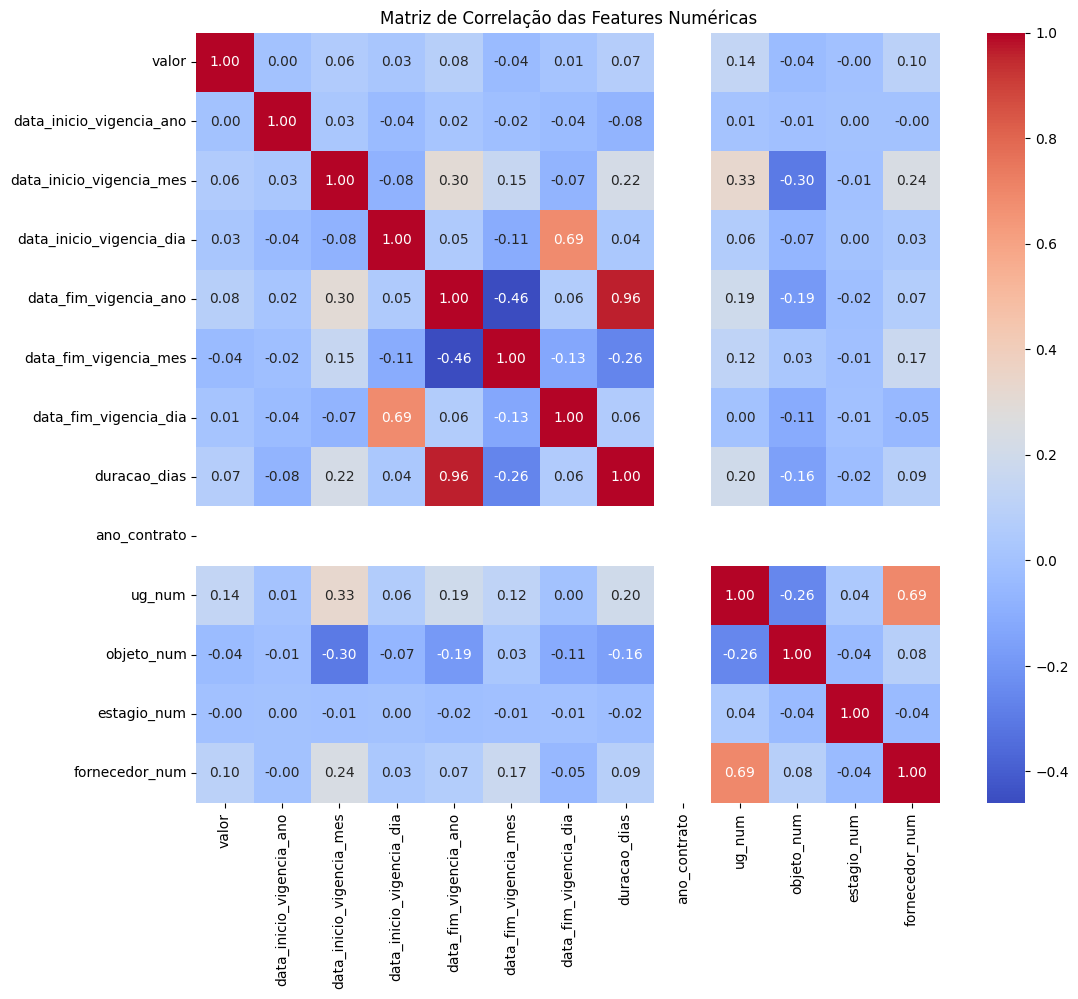

In [ ]:
# Cálculo da matriz de correlação
correlation_matrix = df_contratos.corr()

# Plotagem da matriz
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação das Features Numéricas')
plt.show()

4.4 Remoção de features com correlação baixa com "ug_num"

In [ ]:
columns_to_remove = ["ano_contrato", "data_inicio_vigencia_ano", "data_inicio_vigencia_dia", "data_fim_vigencia_dia", "estagio_num"]
df_contratos = df_contratos.drop(columns=columns_to_remove, errors='ignore')

print(f"Colunas '{', '.join(columns_to_remove)}' removidas.")
df_contratos.info()

Colunas 'ano_contrato, data_inicio_vigencia_ano, data_inicio_vigencia_dia, data_fim_vigencia_dia, estagio_num' removidas.
<class 'pandas.core.frame.DataFrame'>
Index: 2045 entries, 0 to 2046
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   valor                     2045 non-null   float64
 1   data_inicio_vigencia_mes  2045 non-null   int32  
 2   data_fim_vigencia_ano     2045 non-null   float64
 3   data_fim_vigencia_mes     2045 non-null   float64
 4   duracao_dias              2045 non-null   float64
 5   ug_num                    2045 non-null   int64  
 6   objeto_num                2045 non-null   int64  
 7   fornecedor_num            2045 non-null   int64  
dtypes: float64(4), int32(1), int64(3)
memory usage: 135.8 KB


In [ ]:
# Contagem das classes
counts = df_contratos['ug_num'].value_counts()

# Filtragem das classes que aparecem mais de 1 vez
top_ugs = counts[counts > 1].index

# Criação da coluna agrupada com as classes frequentes (resto vira -1)
df_contratos['ug_grouped'] = df_contratos['ug_num'].where(
    df_contratos['ug_num'].isin(top_ugs), -1
)

# Reindexação sequencial
df_contratos['ug_grouped'], _ = pd.factorize(df_contratos['ug_grouped'])

4.5 Divisão dos dados para treinamento. A variável alvo é a "ug_num" e as demais são as entradas dos modelos.

In [ ]:
# Definição das features (X) e o target (y)
X = df_contratos.drop('ug_grouped', axis=1)
y = df_contratos['ug_grouped']

# Divisão treino/validação/teste
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=SEED, stratify=y_temp
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

print("Treino:", X_train.shape)
print("Validação:", X_val.shape)
print("Teste:", X_test.shape)

Treino: (1227, 8)
Validação: (409, 8)
Teste: (409, 8)


4.6 Visualização dos dados do treino

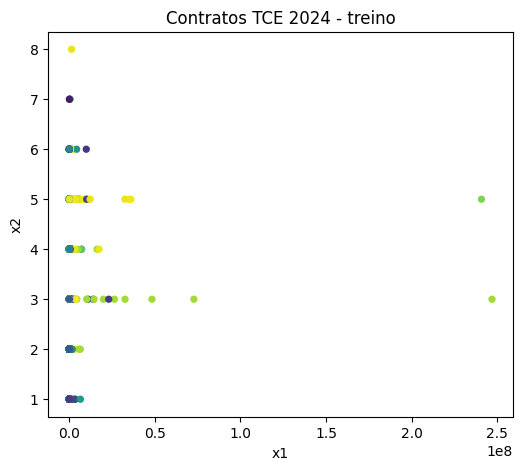

In [ ]:
# Visualização dos dados de treino
plt.figure(figsize=(6, 5))
plt.scatter(X_train.iloc[:, 0], X_train.iloc[:, 1], c=y_train, s=18)
plt.title("Contratos TCE 2024 - treino")
plt.xlabel("x1")
plt.ylabel("x2")
plt.show()

5. Modelos de aprendizado de máquina

5.1 Regressão Logística

In [ ]:
log_reg = LogisticRegression()
log_reg.fit(X_train_s, y_train)

# Avaliação do modelo RL
y_pred_log = log_reg.predict(X_test_s)

print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log, average='weighted'))
print("Recall:", recall_score(y_test, y_pred_log, average='weighted'))
print("F1-score:", f1_score(y_test, y_pred_log, average='weighted'))

Accuracy: 0.706601466992665
Precision: 0.6318310931969215
Recall: 0.706601466992665
F1-score: 0.6601896080974531


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


5.2  MLP

In [ ]:
num_classes = int(y_train.max()) + 1

mlp = keras.Sequential([
    layers.Input(shape=(X_train_s.shape[1],)),
    layers.Dense(16, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(num_classes, activation="softmax")
])

mlp.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_mlp = mlp.fit(
    X_train_s, y_train,
    validation_data=(X_val_s, y_val),
    epochs=40,
    batch_size=32,
    verbose=1
)

print("Treinamento concluído.")

Epoch 1/40
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.0350 - loss: 3.9423 - val_accuracy: 0.1174 - val_loss: 3.7902
Epoch 2/40
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4279 - loss: 3.6230 - val_accuracy: 0.5770 - val_loss: 3.3856
Epoch 3/40
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5835 - loss: 3.0733 - val_accuracy: 0.5844 - val_loss: 2.6657
Epoch 4/40
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5786 - loss: 2.3478 - val_accuracy: 0.5795 - val_loss: 2.0918
Epoch 5/40
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5827 - loss: 1.9884 - val_accuracy: 0.5966 - val_loss: 1.8938
Epoch 6/40
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6055 - loss: 1.8223 - val_accuracy: 0.6259 - val_loss: 1.7657
Epoch 7/40
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6227 - loss: 1.6999 - val_accuracy: 0.6259 - val_loss: 1.6690
Epoch 8/40
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6235 - loss: 1.6025 - val_accuracy: 0.6455 - val_loss

In [ ]:
# Avaliação do modelo MLP
y_pred_probs = mlp.predict(X_test_s, verbose=0)
y_pred_mlp = np.argmax(y_pred_probs, axis=1)

print("Accuracy:", accuracy_score(y_test, y_pred_mlp))
print("Precision:", precision_score(y_test, y_pred_mlp, average='weighted', zero_division=0))
print("Recall:", recall_score(y_test, y_pred_mlp, average='weighted', zero_division=0))
print("F1-score:", f1_score(y_test, y_pred_mlp, average='weighted', zero_division=0))


Accuracy: 0.6968215158924206
Precision: 0.6438641890989834
Recall: 0.6968215158924206
F1-score: 0.6580101649671104


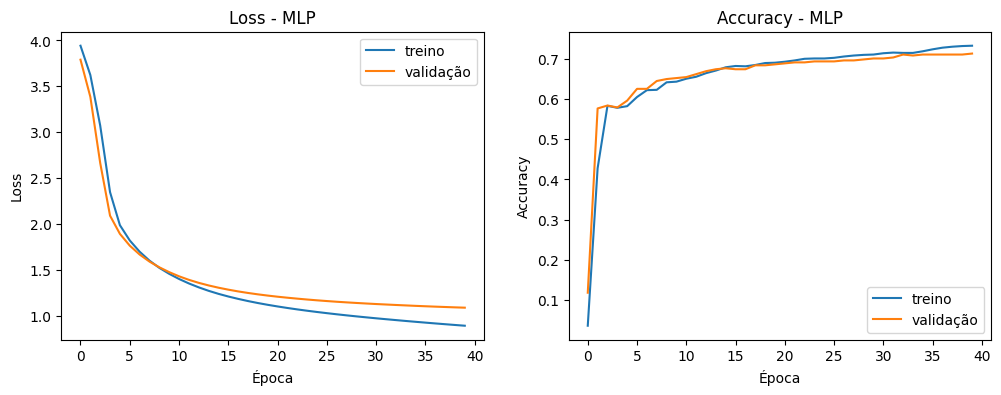

In [ ]:
# Curvas de treino para MLP
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_mlp.history["loss"], label="treino")
plt.plot(history_mlp.history["val_loss"], label="validação")
plt.title("Loss - MLP")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_mlp.history["accuracy"], label="treino")
plt.plot(history_mlp.history["val_accuracy"], label="validação")
plt.title("Accuracy - MLP")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

5.3 CNN

In [ ]:
cnn = keras.Sequential([
    layers.Input(shape=(X_train_cnn.shape[1], 1)),
    layers.Conv1D(filters=32, kernel_size=2, activation='relu'),
    layers.MaxPooling1D(pool_size=2),
    layers.Flatten(),
    layers.Dense(32, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_cnn = cnn.fit(
    X_train_cnn, y_train,
    validation_data=(X_val_cnn, y_val),
    epochs=40,
    batch_size=32,
    verbose=1
)

print("Treinamento CNN concluído.")

Epoch 1/40
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.3830 - loss: 3.8309 - val_accuracy: 0.5257 - val_loss: 3.5201
Epoch 2/40
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4817 - loss: 3.0738 - val_accuracy: 0.4890 - val_loss: 2.5842
Epoch 3/40
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5037 - loss: 2.3277 - val_accuracy: 0.5501 - val_loss: 2.1454
Epoch 4/40
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5640 - loss: 2.0080 - val_accuracy: 0.5770 - val_loss: 1.9061
Epoch 5/40
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5860 - loss: 1.7972 - val_accuracy: 0.5868 - val_loss: 1.7341
Epoch 6/40
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6218 - loss: 1.6357 - val_accuracy: 0.6210 - val_loss: 1.6047
Epoch 7/40
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6381 - loss: 1.5099 - val_accuracy: 0.6357 - val_loss: 1.5070
Epoch 8/40
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6577 - loss: 1.4118 - val_accuracy: 0.6553 - val_loss:

In [ ]:
# Avaliação do modelo CNN
y_pred_probs_cnn = cnn.predict(X_test_cnn, verbose=0)
y_pred_cnn = np.argmax(y_pred_probs_cnn, axis=1)

print("CNN Accuracy:", accuracy_score(y_test, y_pred_cnn))
print("CNN Precision:", precision_score(y_test, y_pred_cnn, average='weighted', zero_division=0))
print("CNN Recall:", recall_score(y_test, y_pred_cnn, average='weighted', zero_division=0))
print("CNN F1-score:", f1_score(y_test, y_pred_cnn, average='weighted', zero_division=0))


CNN Accuracy: 0.7359413202933985
CNN Precision: 0.7021291327526047
CNN Recall: 0.7359413202933985
CNN F1-score: 0.7081039572341946


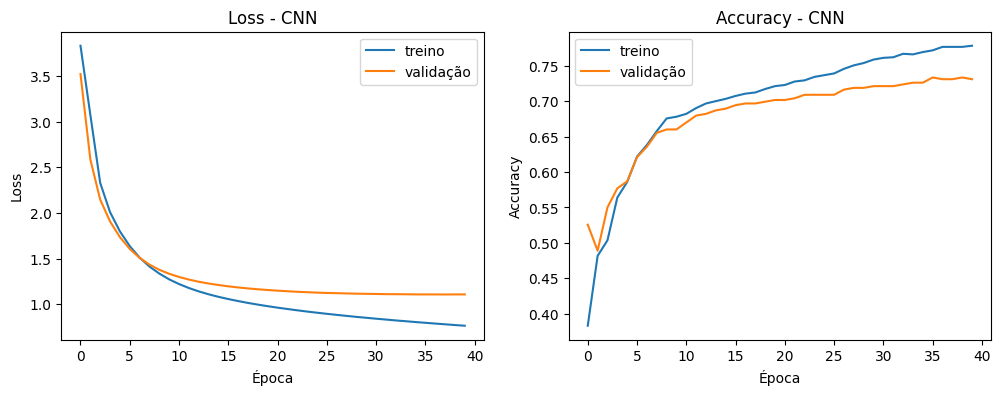

In [ ]:
# Curvas de treino para CNN
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_cnn.history["loss"], label="treino")
plt.plot(history_cnn.history["val_loss"], label="validação")
plt.title("Loss - CNN")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_cnn.history["accuracy"], label="treino")
plt.plot(history_cnn.history["val_accuracy"], label="validação")
plt.title("Accuracy - CNN")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

6. Comparação entre os modelos

In [ ]:
results = pd.DataFrame([
    {
        "Modelo": "Regressão Logística",
        "Accuracy": accuracy_score(y_test, y_pred_log),
        "Precision_macro": precision_score(y_test, y_pred_log, average="macro", zero_division=0),
        "Recall_macro": recall_score(y_test, y_pred_log, average="macro", zero_division=0),
        "F1_macro": f1_score(y_test, y_pred_log, average="macro", zero_division=0),
    },
    {
        "Modelo": "MLP",
        "Accuracy": accuracy_score(y_test, y_pred_mlp),
        "Precision_macro": precision_score(y_test, y_pred_mlp, average="macro", zero_division=0),
        "Recall_macro": recall_score(y_test, y_pred_mlp, average="macro", zero_division=0),
        "F1_macro": f1_score(y_test, y_pred_mlp, average="macro", zero_division=0),
    },
    {
        "Modelo": "CNN",
        "Accuracy": accuracy_score(y_test, y_pred_cnn),
        "Precision_macro": precision_score(y_test, y_pred_cnn, average="macro", zero_division=0),
        "Recall_macro": recall_score(y_test, y_pred_cnn, average="macro", zero_division=0),
        "F1_macro": f1_score(y_test, y_pred_cnn, average="macro", zero_division=0),
    }
])

results.sort_values("F1_macro", ascending=False)

,Modelo,Accuracy,Precision_macro,Recall_macro,F1_macro
2,CNN,0.735941,0.255854,0.257735,0.238973
0,Regressão Logística,0.706601,0.175058,0.198806,0.177097
1,MLP,0.696822,0.168828,0.186218,0.163425
